#### **DiD Models, Sample Design**

- Model 1: a nationwide border-county main sample used for the headline estimate.

- Model 2: a smaller illustrative border sample used for intuition, visuals, and later event-study work.

Notebook roadmap:

1. Research question

2. Main sample and illustrative sample

3. Model 1: nationwide main specification

4. Early results from Model 1

5. Robustness checks for Model 1

6. Continuous Treatment Robustness

7. Model 2: illustrative border sample

8. Interpretation

##### **1. Research Question**

Main question: Does raising the minimum wage reduce employment in low-wage border counties, especially in food services?

We keep `NAICS 722` as the anchor industry because:

- it is the closest match to the classic border-county minimum wage literature,

- it is highly exposed to minimum wage policy,

- and it gives us the clearest first headline result before extending to other sectors.

We also track `log_wage` alongside `log_emp` because wage pass-through is an important first-stage validation.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_colwidth", None)

CWD = Path().resolve()
ROOT = CWD if (CWD / "data" / "intermediate").exists() else CWD.parent
INTERMEDIATE = ROOT / "data" / "intermediate"
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

PANEL_FILE = PROCESSED / "analysis_panel.parquet"
PAIRS_FILE = INTERMEDIATE / "border_pairs.parquet"

PRIMARY_INDUSTRY = "722"
INDUSTRIES = ["722", "44-45", "72", "721"]
SELECTED_BORDERS = ["NJ - PA", "MN - WI", "NY - PA", "CA - NV"]

print("Figures will be saved to:", FIGURES.relative_to(ROOT))

Figures will be saved to: notebooks/figures


##### **2. Main Sample and Illustrative Sample**

**Model 1: nationwide main sample**

This is our preferred sample for the main estimate.

It uses all eligible border-county pairs nationwide that appear in the final analysis panel.

**Model 2: illustrative border sample**

For visuals and later event-study work, we use four state borders:
- `NJ - PA`

- `MN - WI`

- `NY - PA`

- `CA - NV`

We choose these borders because they combine:

- clear and persistent minimum wage divergence,

- enough county-pair coverage,

- strong data completeness in `NAICS 722`,

- and a close fit with the project's border-county story.

The two models are complements, not competing main models:

- Model 1 estimates the average effect across the nationwide border-county sample.

- Model 2 gives us a smaller, more intuitive set of border comparisons for plots and extension work.


In [2]:
panel = pd.read_parquet(PANEL_FILE).copy()
pairs = pd.read_parquet(PAIRS_FILE).copy()

panel["industry_code"] = panel["industry_code"].astype(str)
panel["pair_id"] = panel["pair_id"].astype(int)
panel["year"] = panel["year"].astype(int)
panel["pair_year"] = panel["pair_id"].astype(str) + "_" + panel["year"].astype(str)
panel["mw_gap"] = panel["min_wage"] - panel["partner_min_wage"]
panel["mw_gap_abs"] = panel["mw_gap"].abs()
panel["complete_pair_year"] = (
    panel.groupby(["pair_id", "year", "industry_code"])["area_fips"].transform(
        "nunique"
    )
    == 2
)

pairs["border"] = pairs.apply(
    lambda row: " - ".join(sorted([str(row["state1"]), str(row["state2"])])), axis=1
)
panel = panel.merge(pairs[["pair_id", "border"]], on="pair_id", how="left")

main_sample = panel.copy()
main_722 = main_sample.loc[main_sample["industry_code"] == PRIMARY_INDUSTRY].copy()
illustrative_sample = main_sample.loc[
    main_sample["border"].isin(SELECTED_BORDERS)
].copy()
illustrative_722 = illustrative_sample.loc[
    illustrative_sample["industry_code"] == PRIMARY_INDUSTRY
].copy()

sample_summary = pd.DataFrame(
    {
        "rows": [
            len(main_sample),
            len(main_722),
            len(illustrative_sample),
            len(illustrative_722),
        ],
        "pair_ids": [
            main_sample["pair_id"].nunique(),
            main_722["pair_id"].nunique(),
            illustrative_sample["pair_id"].nunique(),
            illustrative_722["pair_id"].nunique(),
        ],
        "counties": [
            main_sample["area_fips"].nunique(),
            main_722["area_fips"].nunique(),
            illustrative_sample["area_fips"].nunique(),
            illustrative_722["area_fips"].nunique(),
        ],
        "borders": [
            main_sample["border"].nunique(),
            main_722["border"].nunique(),
            illustrative_sample["border"].nunique(),
            illustrative_722["border"].nunique(),
        ],
        "years": [
            main_sample["year"].nunique(),
            main_722["year"].nunique(),
            illustrative_sample["year"].nunique(),
            illustrative_722["year"].nunique(),
        ],
        "mean_abs_gap": [
            main_sample["mw_gap_abs"].mean(),
            main_722["mw_gap_abs"].mean(),
            illustrative_sample["mw_gap_abs"].mean(),
            illustrative_722["mw_gap_abs"].mean(),
        ],
    },
    index=["M1 all industries", "M1 NAICS 722", "M2 all industries", "M2 NAICS 722"],
)

sample_summary.round(3)

,rows,pair_ids,counties,borders,years,mean_abs_gap
M1 all industries,104245,1055,961,99,15,1.590
M1 NAICS 722,26363,1052,925,99,15,1.592
M2 all industries,8016,70,73,4,15,2.450
M2 NAICS 722,1997,70,72,4,15,2.454


In [3]:
selected_border_summary = (
    illustrative_722.groupby("border")
    .agg(
        county_pairs=("pair_id", "nunique"),
        counties=("area_fips", "nunique"),
        rows=("pair_id", "size"),
        mean_gap=("mw_gap_abs", "mean"),
        max_gap=("mw_gap_abs", "max"),
    )
    .reset_index()
)

selected_pair_year = illustrative_722.groupby(
    ["border", "pair_id", "year"], as_index=False
).agg(
    n_counties=("area_fips", "nunique"),
    min_mw=("min_wage", "min"),
    max_mw=("min_wage", "max"),
)
selected_pair_year["positive_gap"] = (
    selected_pair_year["max_mw"] - selected_pair_year["min_mw"]
) > 0

selected_pair_year_summary = (
    selected_pair_year.groupby("border")
    .agg(
        pair_years=("year", "size"),
        gap_pair_years=("positive_gap", "sum"),
        complete_pair_years=("n_counties", lambda s: (s == 2).sum()),
    )
    .reset_index()
)
selected_pair_year_summary["gap_share"] = (
    selected_pair_year_summary["gap_pair_years"]
    / selected_pair_year_summary["pair_years"]
)
selected_pair_year_summary["complete_share"] = (
    selected_pair_year_summary["complete_pair_years"]
    / selected_pair_year_summary["pair_years"]
)

selected_border_table = selected_border_summary.merge(
    selected_pair_year_summary, on="border"
)
selected_border_table.round(3)

,border,county_pairs,counties,rows,mean_gap,max_gap,pair_years,gap_pair_years,complete_pair_years,gap_share,complete_share
0,CA - NV,17,18,463,2.303,6.00,255,208,208,0.816,0.816
1,MN - WI,23,23,642,2.138,3.60,345,297,297,0.861,0.861
2,NJ - PA,12,13,360,2.504,7.88,180,132,180,0.733,1.000
3,NY - PA,18,19,532,2.931,8.75,270,190,262,0.704,0.970


##### **3. Model 1: Nationwide Main Specification**

Our preferred main specification is:

$ \log(emp_{cpt}) = \beta \log(mw_{st}) + \alpha_c + \delta_{pt} + \varepsilon_{cpt} $

where:

- `c` = county

- `p` = border pair

- `t` = year

- `alpha_c` = county fixed effects

- `delta_pt` = pair × year fixed effects

Why we use this for **Model 1**:

- county fixed effects absorb permanent county differences,

- pair × year fixed effects keep the comparison local to the same border in the same year,

- and the nationwide sample gives us the cleanest average-effect estimate.

Implementation detail:

- We use `statsmodels` for estimation and clustered standard errors.

- We first absorb the high-dimensional fixed effects by iterative demeaning, then run OLS on the residualized variables.


In [4]:
def alternating_demean(frame, value_cols, fe_cols, max_iter=200, tol=1e-10):
    resid = frame[value_cols].astype(float).copy()
    last_delta = np.nan

    for n_iter in range(1, max_iter + 1):
        prev = resid.to_numpy(copy=True)
        for fe in fe_cols:
            resid = resid - resid.groupby(frame[fe]).transform("mean")
        last_delta = float(np.max(np.abs(resid.to_numpy() - prev)))
        if last_delta < tol:
            break

    return resid, n_iter, last_delta


def absorbed_ols(frame, y_col, x_col, fe_cols, cluster_col):
    resid, n_iter, last_delta = alternating_demean(frame, [y_col, x_col], fe_cols)
    y_tilde = resid[y_col]
    x_tilde = resid[[x_col]]

    fit = sm.OLS(y_tilde, x_tilde).fit(
        cov_type="cluster",
        cov_kwds={"groups": frame[cluster_col]},
    )

    ssr = float(np.sum((y_tilde - fit.fittedvalues) ** 2))
    sst = float(np.sum(y_tilde**2))
    within_r2 = np.nan if sst == 0 else 1 - ssr / sst

    return {
        "fit": fit,
        "beta": float(fit.params[x_col]),
        "se": float(fit.bse[x_col]),
        "t_stat": float(fit.tvalues[x_col]),
        "p_value": float(fit.pvalues[x_col]),
        "within_r2": within_r2,
        "n_obs": int(fit.nobs),
        "n_clusters": int(pd.Series(frame[cluster_col]).nunique()),
        "absorbing_iterations": n_iter,
        "final_delta": last_delta,
    }


def tidy_result(label, result):
    return {
        "model": label,
        "beta": result["beta"],
        "cluster_se": result["se"],
        "t_stat": result["t_stat"],
        "p_value": result["p_value"],
        "within_r2": result["within_r2"],
        "n_obs": result["n_obs"],
        "n_clusters": result["n_clusters"],
    }


model1_emp_722 = absorbed_ols(
    main_722,
    y_col="log_emp",
    x_col="log_min_wage",
    fe_cols=["area_fips", "pair_year"],
    cluster_col="pair_id",
)

model1_wage_722 = absorbed_ols(
    main_722,
    y_col="log_wage",
    x_col="log_min_wage",
    fe_cols=["area_fips", "pair_year"],
    cluster_col="pair_id",
)

headline_results = pd.DataFrame(
    [
        tidy_result("M1 722 employment", model1_emp_722),
        tidy_result("M1 722 wages", model1_wage_722),
    ]
)

for col in ["beta", "cluster_se", "t_stat", "p_value", "within_r2"]:
    headline_results[col] = headline_results[col].round(4)

headline_results

,model,beta,cluster_se,t_stat,p_value,within_r2,n_obs,n_clusters
0,M1 722 employment,-0.0272,0.0205,-1.3254,0.185,0.0009,26363,1052
1,M1 722 wages,0.1393,0.0103,13.4807,0.000,0.0676,26363,1052


##### **4. Early Results From Model 1**

- We compare employment and wage elasticities across the four industry definitions,

- We produce a simple coefficient chart so we can quickly see where the strongest patterns are.

Results:
- `log_wage` is our pass-through / first-stage check.

- `log_emp` is our main outcome.

- `722` is still the anchor industry for interpretation.

Notes:
- `72` is a broader aggregate that overlaps with `721` and `722`.

- We therefore use `722` as the anchor result and treat the other rows as heterogeneity or benchmark checks, not four fully independent industries.


In [5]:
industry_results = []
for industry in INDUSTRIES:
    sample = main_sample.loc[main_sample["industry_code"] == industry].copy()
    emp_result = absorbed_ols(
        sample,
        y_col="log_emp",
        x_col="log_min_wage",
        fe_cols=["area_fips", "pair_year"],
        cluster_col="pair_id",
    )
    wage_result = absorbed_ols(
        sample,
        y_col="log_wage",
        x_col="log_min_wage",
        fe_cols=["area_fips", "pair_year"],
        cluster_col="pair_id",
    )
    industry_results.append(
        {
            "industry_code": industry,
            "n_rows": len(sample),
            "pair_ids": sample["pair_id"].nunique(),
            "emp_beta": emp_result["beta"],
            "emp_se": emp_result["se"],
            "wage_beta": wage_result["beta"],
            "wage_se": wage_result["se"],
        }
    )

industry_results = pd.DataFrame(industry_results)
for col in ["emp_beta", "emp_se", "wage_beta", "wage_se"]:
    industry_results[col] = industry_results[col].round(4)

industry_results

,industry_code,n_rows,pair_ids,emp_beta,emp_se,wage_beta,wage_se
0,722,26363,1052,-0.0272,0.0205,0.1393,0.0103
1,44-45,31182,1055,0.0074,0.0147,0.0356,0.0090
2,72,25065,1044,0.0005,0.0214,0.1302,0.0119
3,721,21635,984,-0.0124,0.0489,0.0697,0.0183


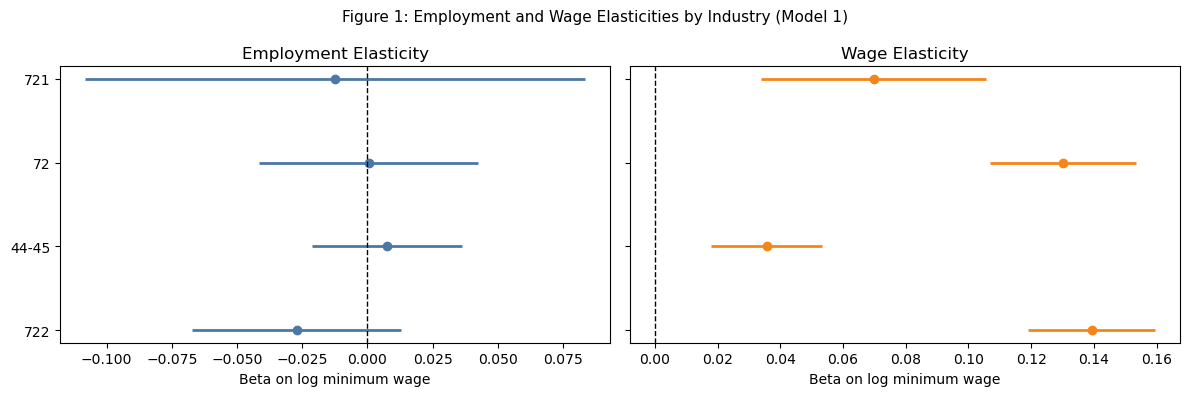

Figure 1 saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_df = industry_results.copy()
plot_df["emp_lo"] = plot_df["emp_beta"] - 1.96 * plot_df["emp_se"]
plot_df["emp_hi"] = plot_df["emp_beta"] + 1.96 * plot_df["emp_se"]
plot_df["wage_lo"] = plot_df["wage_beta"] - 1.96 * plot_df["wage_se"]
plot_df["wage_hi"] = plot_df["wage_beta"] + 1.96 * plot_df["wage_se"]

y = np.arange(len(plot_df))

axes[0].hlines(y, plot_df["emp_lo"], plot_df["emp_hi"], color="#4C78A8", lw=2)
axes[0].plot(plot_df["emp_beta"], y, "o", color="#4C78A8")
axes[0].axvline(0, color="black", ls="--", lw=1)
axes[0].set_title("Employment Elasticity")
axes[0].set_xlabel("Beta on log minimum wage")
axes[0].set_yticks(y)
axes[0].set_yticklabels(plot_df["industry_code"])

axes[1].hlines(y, plot_df["wage_lo"], plot_df["wage_hi"], color="#F58518", lw=2)
axes[1].plot(plot_df["wage_beta"], y, "o", color="#F58518")
axes[1].axvline(0, color="black", ls="--", lw=1)
axes[1].set_title("Wage Elasticity")
axes[1].set_xlabel("Beta on log minimum wage")
axes[1].set_yticks(y)
axes[1].set_yticklabels(plot_df["industry_code"])

plt.suptitle(
    "Figure 1: Employment and Wage Elasticities by Industry (Model 1)", fontsize=11
)
plt.tight_layout()
plt.savefig(FIGURES / "fig1_industry_elasticities.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved.")

Interpretation: 

Wage elasticities are clearly positive across all four industry definitions, with the strongest pass-through in `722` and `72`. Employment elasticities, by contrast, stay close to zero and have much wider uncertainty bands. This is why the current evidence is strongest on wage pass-through and more cautious on employment loss.


##### **5. Robustness Checks for Model 1**

Before treating Model 1 as the headline estimate, we check whether the `NAICS 722` result is sensitive to:

- the clustering level (`pair_id` vs `area_fips`),

- the fixed-effects structure,

- dropping 2020,

- and restricting to complete pair-years with both sides observed.


In [7]:
model1_cluster_sensitivity = []
for outcome, outcome_label in [("log_emp", "Employment"), ("log_wage", "Wage")]:
    for cluster_col, cluster_label in [
        ("pair_id", "pair_id"),
        ("area_fips", "area_fips"),
    ]:
        result = absorbed_ols(
            main_722,
            y_col=outcome,
            x_col="log_min_wage",
            fe_cols=["area_fips", "pair_year"],
            cluster_col=cluster_col,
        )
        model1_cluster_sensitivity.append(
            {
                "outcome": outcome_label,
                "cluster": cluster_label,
                "beta": result["beta"],
                "se": result["se"],
                "t_stat": result["t_stat"],
                "p_value": result["p_value"],
                "clusters": result["n_clusters"],
            }
        )

model1_cluster_sensitivity = pd.DataFrame(model1_cluster_sensitivity)
for col in ["beta", "se", "t_stat", "p_value"]:
    model1_cluster_sensitivity[col] = model1_cluster_sensitivity[col].round(4)

model1_cluster_sensitivity

,outcome,cluster,beta,se,t_stat,p_value,clusters
0,Employment,pair_id,-0.0272,0.0205,-1.3254,0.185,1052
1,Employment,area_fips,-0.0272,0.0186,-1.4646,0.143,925
2,Wage,pair_id,0.1393,0.0103,13.4807,0.000,1052
3,Wage,area_fips,0.1393,0.0095,14.6158,0.000,925


In [8]:
model1_spec_checks = []
for spec_label, sample, fe_cols, cluster_col in [
    ("county FE + year FE", main_722, ["area_fips", "year"], "area_fips"),
    ("preferred FE", main_722, ["area_fips", "pair_year"], "pair_id"),
    (
        "preferred FE, drop 2020",
        main_722.loc[main_722["year"] != 2020].copy(),
        ["area_fips", "pair_year"],
        "pair_id",
    ),
    (
        "preferred FE, complete pair-years",
        main_722.loc[main_722["complete_pair_year"]].copy(),
        ["area_fips", "pair_year"],
        "pair_id",
    ),
]:
    result = absorbed_ols(
        sample,
        y_col="log_emp",
        x_col="log_min_wage",
        fe_cols=fe_cols,
        cluster_col=cluster_col,
    )
    model1_spec_checks.append(
        {
            "spec": spec_label,
            "beta": result["beta"],
            "se": result["se"],
            "t_stat": result["t_stat"],
            "p_value": result["p_value"],
            "n_obs": result["n_obs"],
            "clusters": result["n_clusters"],
        }
    )

model1_spec_checks = pd.DataFrame(model1_spec_checks)
for col in ["beta", "se", "t_stat", "p_value"]:
    model1_spec_checks[col] = model1_spec_checks[col].round(4)

model1_spec_checks

,spec,beta,se,t_stat,p_value,n_obs,clusters
0,county FE + year FE,-0.0148,0.0278,-0.5323,0.5946,26363,925
1,preferred FE,-0.0272,0.0205,-1.3254,0.1850,26363,1052
2,"preferred FE, drop 2020",-0.0247,0.0209,-1.1839,0.2365,24594,1052
3,"preferred FE, complete pair-years",-0.0272,0.0205,-1.3251,0.1851,22318,956


Interpretation: 

The `722` employment coefficient stays negative but modest across the main checks. Changing the clustering level slightly changes the standard error but not the basic conclusion. Dropping 2020 and restricting to complete pair-years also leave the estimate in roughly the same range. This suggests the current headline result is not being driven by a single year or a single sample filter.


##### **6. Continuous Treatment Robustness**

We are also concerned about whether the results are robust when treatment intensity is measured as the dollar gap between a county's minimum wage and its border partner's minimum wage, rather than only by the county's own log minimum wage. With pair × year fixed effects, the absolute gap is absorbed because both counties in a pair-year share the same absolute gap. The estimable intensity check therefore uses the signed gap:

$$mw\_gap_{cpt} = minimum\ wage_{ct} - partner\ minimum\ wage_{pt}$$

This keeps identification within each border pair-year and asks whether the higher-wage side has different employment or wage outcomes than the lower-wage side as the dollar gap widens.

In [9]:
continuous_gap_results = []
for outcome, label in [
    ("log_emp", "Employment"),
    ("log_wage", "Average weekly wage"),
]:
    result = absorbed_ols(
        main_722,
        y_col=outcome,
        x_col="mw_gap",
        fe_cols=["area_fips", "pair_year"],
        cluster_col="pair_id",
    )
    continuous_gap_results.append(
        {
            "outcome": label,
            "treatment": "Signed $ minimum wage gap",
            "beta_per_dollar_gap": result["beta"],
            "se": result["se"],
            "t_stat": result["t_stat"],
            "p_value": result["p_value"],
            "n_obs": result["n_obs"],
            "clusters": result["n_clusters"],
        }
    )

continuous_gap_results = pd.DataFrame(continuous_gap_results)
for col in ["beta_per_dollar_gap", "se", "t_stat", "p_value"]:
    continuous_gap_results[col] = continuous_gap_results[col].round(4)

print("Continuous treatment robustness: signed dollar gap within border pair-years")
print(continuous_gap_results.to_string(index=False))

Continuous treatment robustness: signed dollar gap within border pair-years
            outcome                 treatment  beta_per_dollar_gap     se  t_stat  p_value  n_obs  clusters
         Employment Signed $ minimum wage gap              -0.0012 0.0011 -1.1633   0.2447  26363      1052
Average weekly wage Signed $ minimum wage gap               0.0076 0.0005 14.4115   0.0000  26363      1052


Interpretation: 

The signed minimum-wage-gap check preserves the same border pair-year comparison as the preferred Model 1 specification. A $1 larger minimum wage than the paired county is associated with a very small and statistically insignificant employment difference (β = -0.0012, p = 0.245), while the wage effect is positive and precisely estimated (β = 0.0076, p < 0.001). This robustness check supports the headline conclusion: higher minimum wages clearly raise wages, but we do not find evidence of broad employment losses in NAICS 722.

##### **7. Model 2: Illustrative Border Sample**

For Model 2, we keep the same general identification idea but restrict attention to four illustrative borders:

- `NJ - PA`

- `MN - WI`

- `NY - PA`

- `CA - NV`

This sample is not meant to replace the nationwide main estimate.
Instead, it is meant to help with:
- intuitive border-by-border visuals,

- later event-study graphs,

- and a more concrete discussion of local comparability.

Because the number of pair clusters is much smaller here, the Model 2 coefficients should be treated as descriptive and visual support, not as the main source of statistical inference.


In [10]:
model2_emp_722 = absorbed_ols(
    illustrative_722,
    y_col="log_emp",
    x_col="log_min_wage",
    fe_cols=["area_fips", "pair_year"],
    cluster_col="pair_id",
)

model2_wage_722 = absorbed_ols(
    illustrative_722,
    y_col="log_wage",
    x_col="log_min_wage",
    fe_cols=["area_fips", "pair_year"],
    cluster_col="pair_id",
)

model2_results = pd.DataFrame(
    [
        tidy_result("M2 722 employment", model2_emp_722),
        tidy_result("M2 722 wages", model2_wage_722),
    ]
)

for col in ["beta", "cluster_se", "t_stat", "p_value", "within_r2"]:
    model2_results[col] = model2_results[col].round(4)

model2_results

,model,beta,cluster_se,t_stat,p_value,within_r2,n_obs,n_clusters
0,M2 722 employment,-0.0360,0.0361,-0.9985,0.318,0.0055,1997,70
1,M2 722 wages,0.1758,0.0201,8.7594,0.000,0.2819,1997,70


In [11]:
by_border_results = []
for border in SELECTED_BORDERS:
    border_sample = illustrative_722.loc[illustrative_722["border"] == border].copy()
    border_emp = absorbed_ols(
        border_sample,
        y_col="log_emp",
        x_col="log_min_wage",
        fe_cols=["area_fips", "pair_year"],
        cluster_col="pair_id",
    )
    by_border_results.append(
        {
            "border": border,
            "pair_ids": border_sample["pair_id"].nunique(),
            "n_rows": len(border_sample),
            "emp_beta": border_emp["beta"],
            "emp_se": border_emp["se"],
        }
    )

by_border_results = pd.DataFrame(by_border_results)
for col in ["emp_beta", "emp_se"]:
    by_border_results[col] = by_border_results[col].round(4)

by_border_results

,border,pair_ids,n_rows,emp_beta,emp_se
0,NJ - PA,12,360,-0.0819,0.0504
1,MN - WI,23,642,-0.0230,0.0690
2,NY - PA,18,532,-0.0524,0.0538
3,CA - NV,17,463,0.0824,0.1839


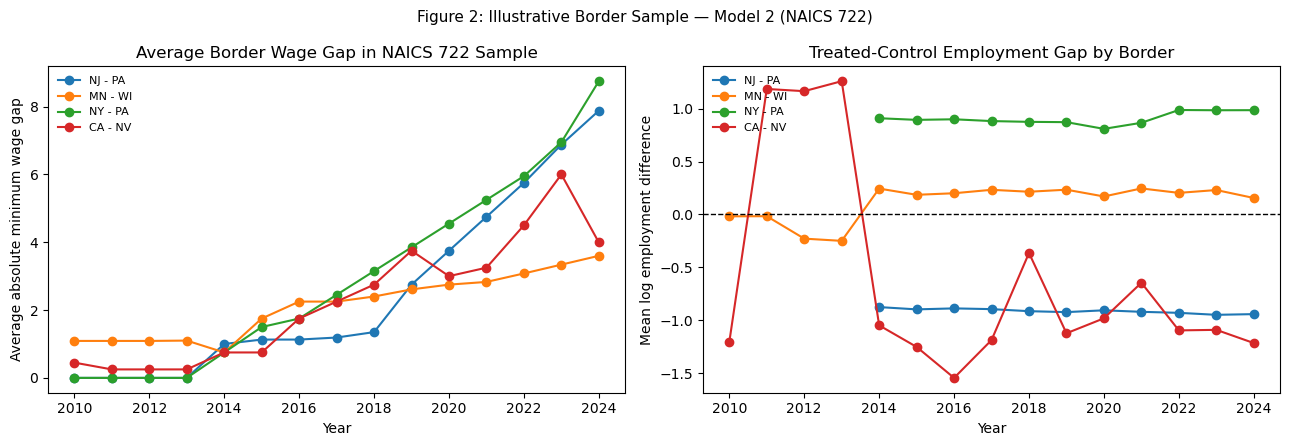

Figure 2 saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

border_gap = illustrative_722.groupby(["border", "year"], as_index=False).agg(
    mean_abs_gap=("mw_gap_abs", "mean")
)
for border in SELECTED_BORDERS:
    tmp = border_gap.loc[border_gap["border"] == border]
    axes[0].plot(tmp["year"], tmp["mean_abs_gap"], marker="o", label=border)
axes[0].set_title("Average Border Wage Gap in NAICS 722 Sample")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average absolute minimum wage gap")
axes[0].legend(frameon=False, fontsize=8)

border_emp_gap = (
    illustrative_722.groupby(["border", "year", "treated"], as_index=False)
    .agg(mean_log_emp=("log_emp", "mean"))
    .pivot(index=["border", "year"], columns="treated", values="mean_log_emp")
    .reset_index()
)
border_emp_gap["treated_minus_control"] = border_emp_gap[1] - border_emp_gap[0]
for border in SELECTED_BORDERS:
    tmp = border_emp_gap.loc[border_emp_gap["border"] == border]
    axes[1].plot(tmp["year"], tmp["treated_minus_control"], marker="o", label=border)
axes[1].axhline(0, color="black", ls="--", lw=1)
axes[1].set_title("Treated-Control Employment Gap by Border")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean log employment difference")
axes[1].legend(frameon=False, fontsize=8)

plt.suptitle("Figure 2: Illustrative Border Sample — Model 2 (NAICS 722)", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "fig2_illustrative_borders.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved.")

Interpretation: 

The four selected borders all show sustained minimum wage divergence, which is why they work well as illustrative cases. The treated-control employment gaps move differently across borders and are visibly noisier than the nationwide average estimate. This is exactly why Model 2 is more useful for intuition and event-study plots than for headline inference.


##### **8. Interpretation**

Current takeaways from this notebook:

- In Model 1, the wage elasticity in `NAICS 722` is clearly positive and precisely estimated. This is strong evidence of wage pass-through.

- The employment elasticity in `NAICS 722` is negative in sign but small and statistically imprecise (little evidence of large employment losses).

- The selected-border Model 2 points in the same general direction as Model 1 for `722`, but the smaller sample makes those estimates noisier.

- Across industries, wage effects are consistently positive. Employment effects remain close to zero or mildly negative.

- Because `72` overlaps with `721` and `722`, it should be described as a broader benchmark rather than a separate independent sector.

- Border-specific estimates, especially for a single border, should be interpreted cautiously because they are based on relatively few clusters.

Summary:

- Our nationwide border-county specification finds strong evidence that minimum wage increases raise wages in food services, while the corresponding employment estimates are small, negative in sign, and statistically imprecise. In other words, the data support clear wage pass-through but provide limited evidence of large employment losses in NAICS 722.
